## Results Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Loading datasets with results from both Random Search and Bayesian Optimization and combining the results for all models to make analysis easier
def load_results(result_type, results_dir="Results"):
    model_files = {
        "Decision Tree": os.path.join(results_dir, f"decisiontree_{result_type}.csv"),
        "KNN": os.path.join(results_dir, f"knn_{result_type}.csv"),
        "XGBoost": os.path.join(results_dir, f"xgboost_{result_type}.csv")
    }

    model_dfs = []
    for model_name, file_path in model_files.items():
        df = pd.read_csv(file_path)
        df["model"] = model_name
        # Number of iterations separately for each dataset within every model
        df["iteration"] = df.groupby("dataset").cumcount() + 1
        model_dfs.append(df)

    return pd.concat(model_dfs, ignore_index=True)

all_bayes = load_results("bayes")
all_random = load_results("uniform")

In [3]:
# Function returns only the increasing points where the model's performance improved
def get_increasing_points(iterations, scores):
    inc_iterations, inc_scores = [], []
    prev_score = None
    for it, sc in zip(iterations, scores):
        if prev_score is None or sc > prev_score:
            inc_iterations.append(it)
            inc_scores.append(sc)
            prev_score = sc
    return inc_iterations, inc_scores

In [4]:
# Function plots all scores from all datasets for each model separately
def plot_all_points(all_df, title_prefix=""):
    models = all_df["model"].unique()

    for model_name in models:
        plt.figure(figsize=(10, 4))
        subset = all_df[all_df["model"] == model_name]

        for dataset_name, group in subset.groupby("dataset"):
            group_sorted = group.sort_values("iteration")

            plt.plot(
                group_sorted["iteration"],
                group_sorted["test_roc_auc"],
                marker='o',
                linestyle='-',
                alpha=0.8,
                label=dataset_name,
                markersize=3,
                linewidth=1
            )

        plt.title(f"{title_prefix}ROC AUC over iterations — {model_name}", fontsize=14)
        plt.xlabel("Iteration")
        plt.ylabel("Test ROC AUC")
        plt.ylim(0, 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(title="Dataset")
        plt.tight_layout()
        plt.show()

In [5]:
# Function plots scores for only the increasing points where the model's performance improved
def plot_auc_trends(all_df, title_prefix=""):
    models = all_df["model"].unique()

    for model_name in models:
        plt.figure(figsize=(10, 4))
        subset = all_df[all_df["model"] == model_name]

        for dataset_name, group in subset.groupby("dataset"):
            group_sorted = group.sort_values("iteration")
            up_iterations, up_scores = get_increasing_points(
                group_sorted["iteration"].values,
                group_sorted["test_roc_auc"].values
            )

            plt.plot(
                up_iterations,
                up_scores,
                marker='o',
                linestyle='-',
                alpha=0.8,
                label=dataset_name,
                markersize=3,
                linewidth=1
            )

        plt.title(f"{title_prefix}ROC AUC over iterations — {model_name} (increasing points only)", fontsize=14)
        plt.xlabel("Iteration")
        plt.ylabel("Test ROC AUC")
        plt.ylim(0, 1)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(title="Dataset")
        plt.tight_layout()
        plt.show()

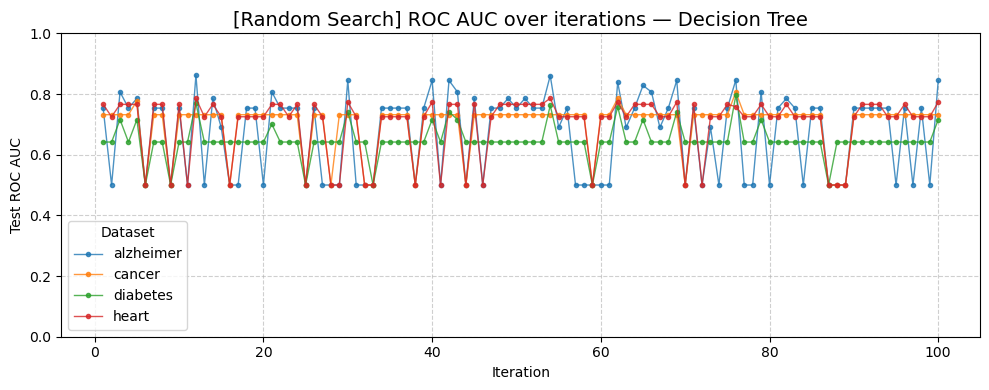

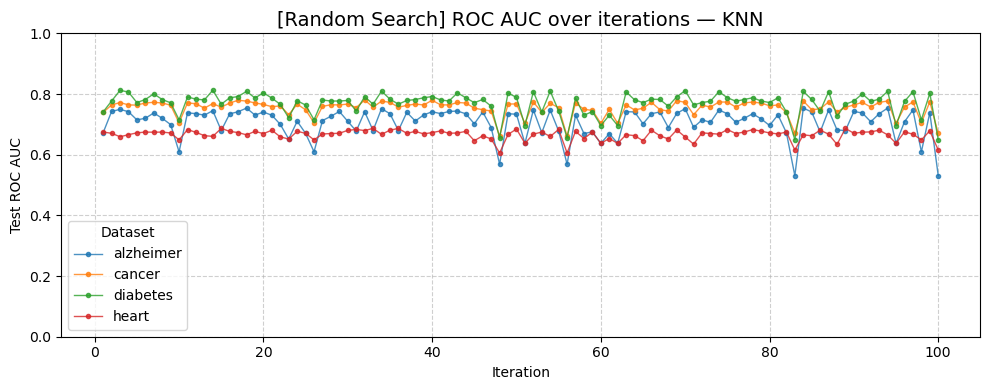

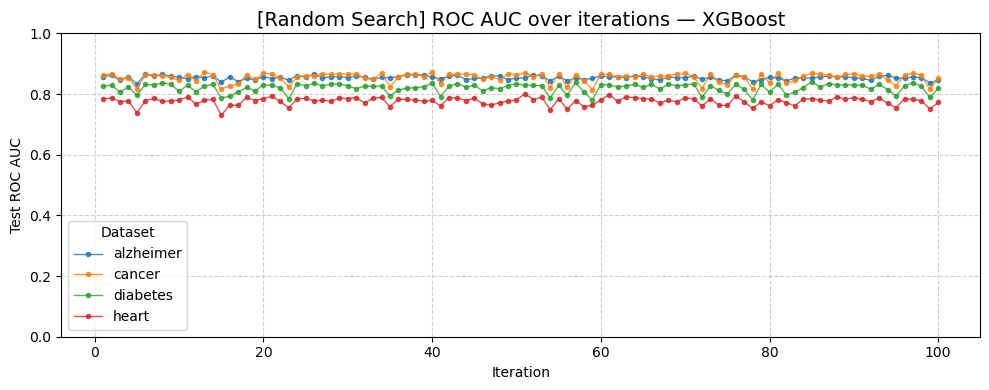

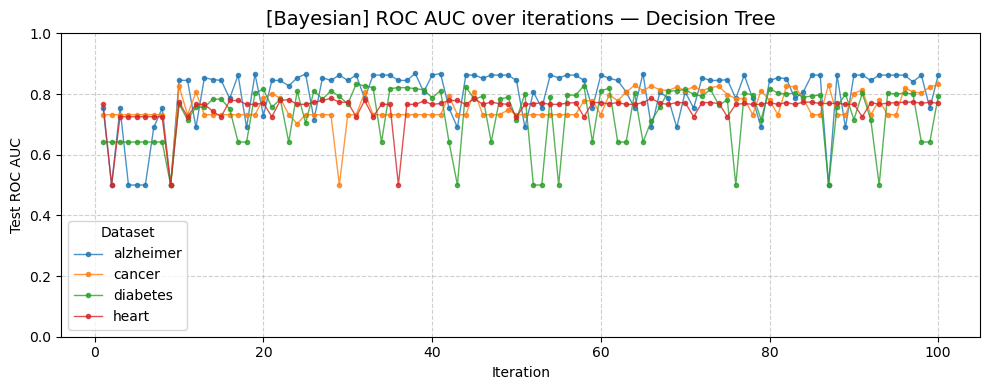

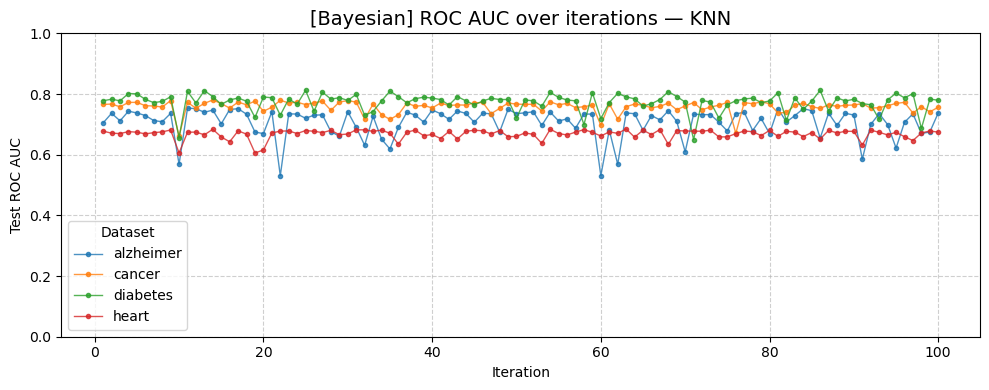

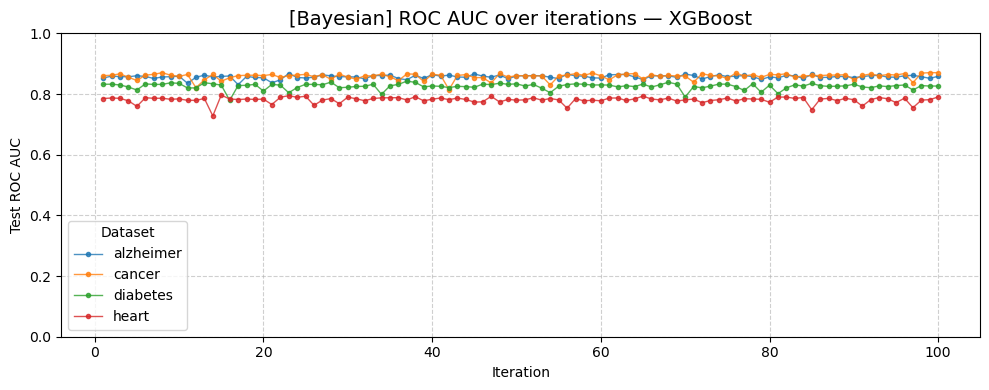

In [6]:
all_bayes = load_results("bayes")
all_random = load_results("uniform")

# Plots all points
plot_all_points(all_random, title_prefix="[Random Search] ")
plot_all_points(all_bayes, title_prefix="[Bayesian] ")

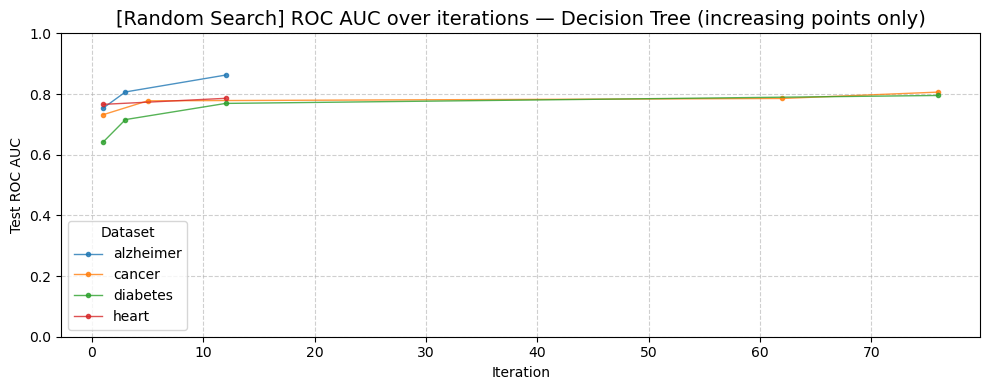

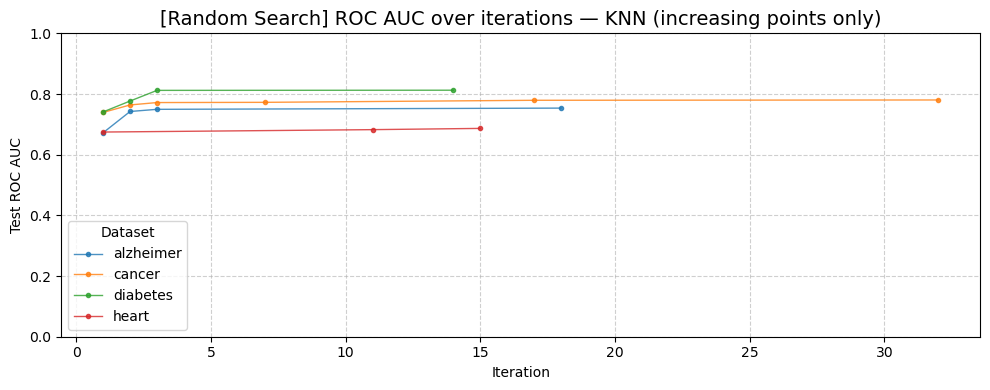

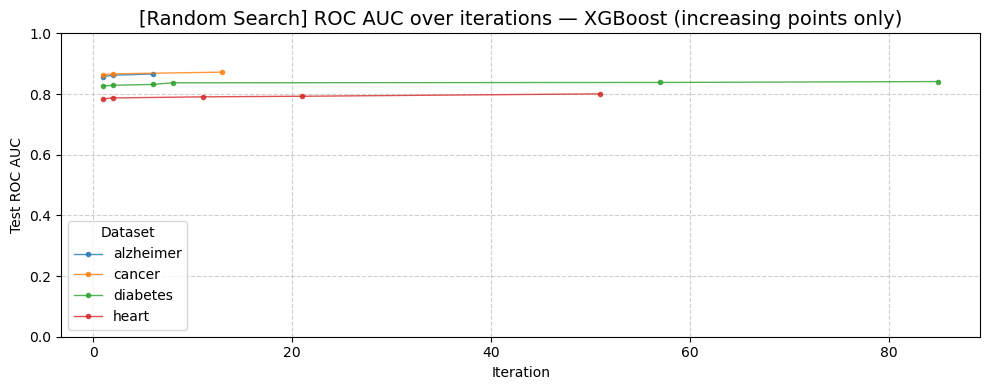

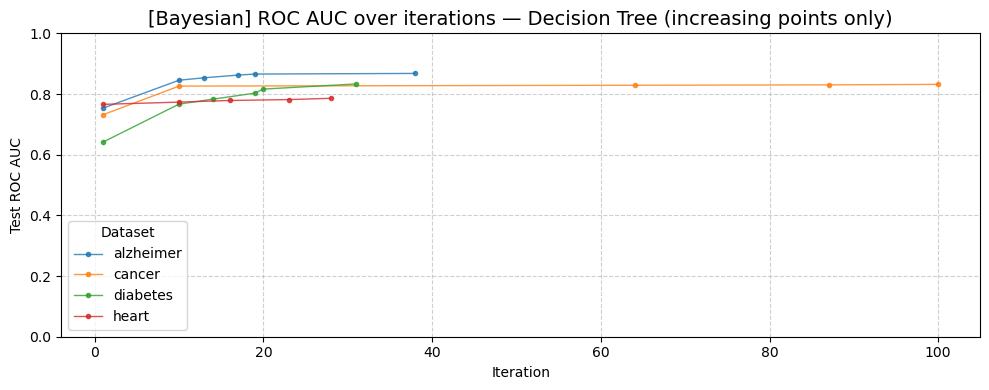

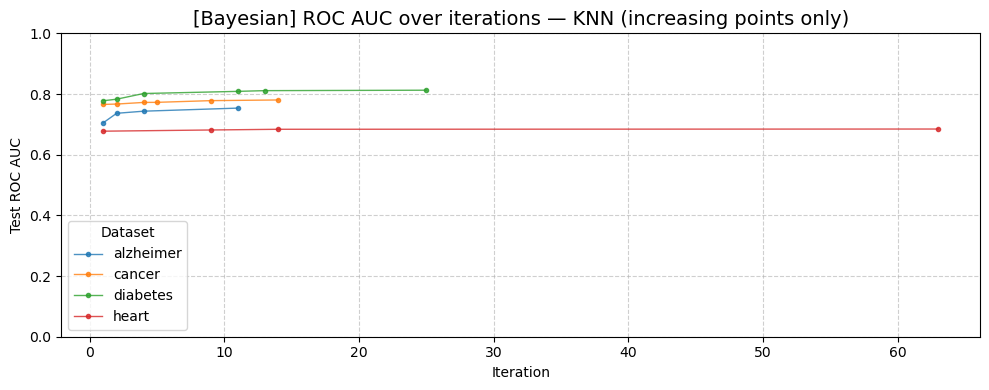

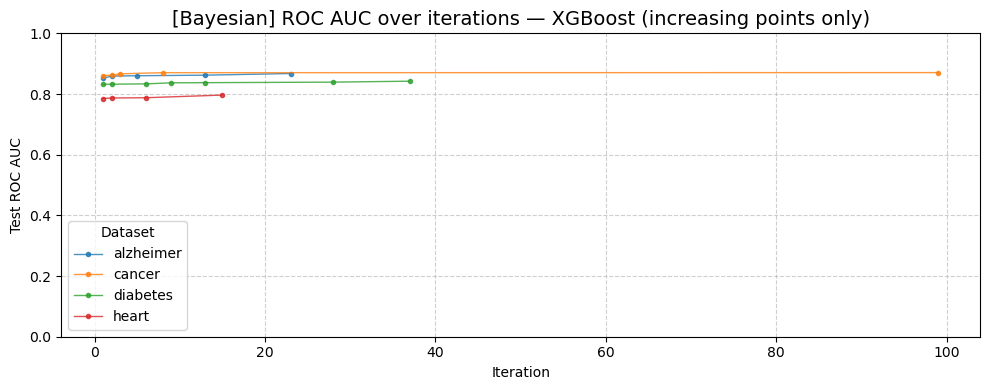

In [7]:
# Plots increasing points only
plot_auc_trends(all_random, title_prefix="[Random Search] ")
plot_auc_trends(all_bayes, title_prefix="[Bayesian] ")

In [8]:
# Boxplots for random distribution of diff_from_star to analyze model tunability
def plot_boxplot_diff_from_star(all_df, title_prefix=""):
    models = all_df['model'].unique()
    data_to_plot = [all_df.loc[all_df['model'] == m, 'diff_from_star'] for m in models]

    plt.figure(figsize=(8, 6))
    plt.boxplot(
        data_to_plot,
        labels=models,
        patch_artist=True,
        medianprops={'color': 'black'},
        boxprops={'facecolor': '#c6dbef', 'color': '#3182bd'},
        whiskerprops={'color': '#3182bd'},
        capprops={'color': '#3182bd'}
    )

    plt.ylabel("Difference from star")
    plt.title(f"{title_prefix}Difference from star per model")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

C:\Users\milek\AppData\Local\Temp\ipykernel_30216\88132348.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


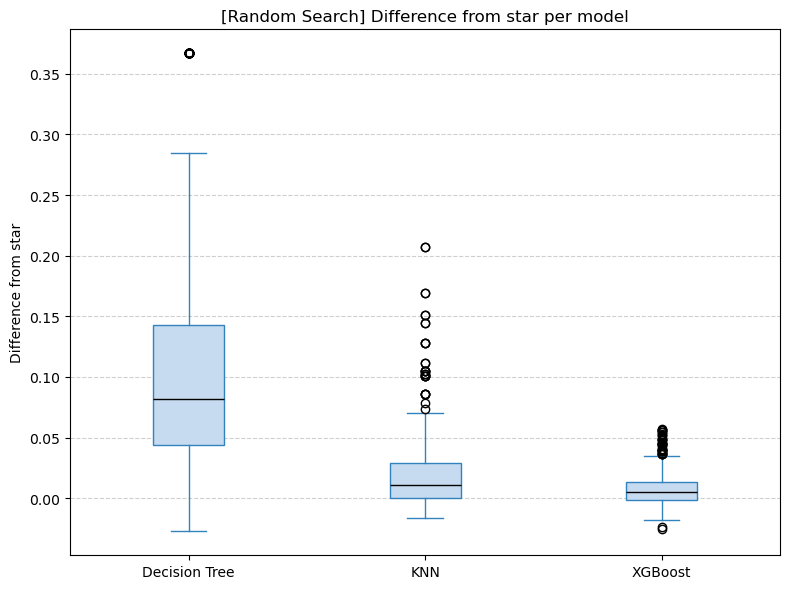

In [9]:
plot_boxplot_diff_from_star(all_random, title_prefix="[Random Search] ")

In [10]:
xgb_random_summary = pd.read_csv("Results/xgboost_uniform_summary.csv")
xgb_bayes_summary = pd.read_csv("Results/xgboost_bayes_summary.csv")
decisiontree_random_summary = pd.read_csv("Results/decisiontree_uniform_summary.csv")
decisiontree_bayes_summary = pd.read_csv("Results/decisiontree_bayes_summary.csv")
knn_random_summary = pd.read_csv("Results/knn_uniform_summary.csv")
knn_bayes_summary = pd.read_csv("Results/knn_bayes_summary.csv")

In [11]:
decisiontree_random_summary

,dataset,ccp_alpha,max_depth,min_samples_leaf,min_samples_split,test_roc_auc,star_test_roc_auc,default_test_roc_auc
0,alzheimer,0.006505,4.0,25.0,15.0,0.862409,0.866969,0.715910
1,cancer,0.000506,14.0,18.0,3.0,0.806296,0.778981,0.702465
2,diabetes,0.000506,14.0,18.0,3.0,0.795224,0.784597,0.704119
3,heart,0.006505,4.0,25.0,15.0,0.785811,0.768783,0.649975
4,STAR,0.003506,9.0,22.0,9.0,NaN,0.799833,NaN


In [12]:
# Function merges summary CSVs for Random Search and Bayesian Optimization results 
# and selects dataset, default, star, random and bayes test roc_auc columns.
def merge_summaries(random_df, bayes_df, model_name):
    merged = random_df.merge(bayes_df, on="dataset", suffixes=("_random", "_bayes"))
    merged = merged.rename(columns={
        "test_roc_auc_random": "random_test_roc_auc",
        "test_roc_auc_bayes": "bayes_test_roc_auc",
        "default_test_roc_auc_random": "default_test_roc_auc"
    })
    merged = merged[["dataset", "default_test_roc_auc", "star_test_roc_auc", "random_test_roc_auc", "bayes_test_roc_auc"]]
    merged["model"] = model_name
    return merged

In [13]:
decisiontree_sum = merge_summaries(decisiontree_random_summary, decisiontree_bayes_summary, "Decision Tree")
decisiontree_sum

,dataset,default_test_roc_auc,star_test_roc_auc,random_test_roc_auc,bayes_test_roc_auc,model
0,alzheimer,0.715910,0.866969,0.862409,0.867869,Decision Tree
1,cancer,0.702465,0.778981,0.806296,0.831729,Decision Tree
2,diabetes,0.704119,0.784597,0.795224,0.833194,Decision Tree
3,heart,0.649975,0.768783,0.785811,0.785811,Decision Tree


In [14]:
knn_sum = merge_summaries(knn_random_summary, knn_bayes_summary, "KNN")
knn_sum

,dataset,default_test_roc_auc,star_test_roc_auc,random_test_roc_auc,bayes_test_roc_auc,model
0,alzheimer,0.676913,0.737553,0.753539,0.753539,KNN
1,cancer,0.735195,0.772560,0.780356,0.780356,KNN
2,diabetes,0.712776,0.800597,0.812537,0.812537,KNN
3,heart,0.669854,0.674140,0.686630,0.684574,KNN


In [15]:
xgb_sum = merge_summaries(xgb_random_summary, xgb_bayes_summary, "XGBoost")
xgb_sum

KeyError: "['default_test_roc_auc', 'star_test_roc_auc'] not in index"

In [ ]:
from scipy.stats import wilcoxon

# Since the number of analyzed datasets was small (n = 4) and the distribution of differences between the results of Random Search and 
# Bayesian Optimization was unknown, a nonparametric Wilcoxon signed-rank test for paired samples was used for comparison.
    
for model_df, model_name in [
    (decisiontree_sum, "Decision Tree"),
    (knn_sum, "KNN"),
    #(xgb_sum, "XGBoost")
]:
    stat, p_val = wilcoxon(
        model_df["bayes_test_roc_auc"],
        model_df["random_test_roc_auc"]
    )
    print(f"{model_name}: p-value = {p_val:.4f}")